# `_prev` covariate 밀도 실험 — 빌드 · 누출 감사 · 학습 · 비교 (all-in-one)

`blaine_prev` / `residue_prev` 를
- **sparse** : 실측 scheduled 행에만 값, 그 사이 NaN (현행 기본값)
- **ffill**  : 직전 실측값을 다음 측정 시점까지 forward-fill (모든 행에 앵커)

두 방식으로 데이터를 만들어 각각 full fine-tuning + backtest 하고 skill-score 를 비교한다.

**정확성 원칙 — 이 노트북이 지키는 것:**
1. 두 arm 은 **동일한 `prepare_base()` 결과**에서 갈라진다 → `_prev` 2개 컬럼 말고는
   행 수·타임스탬프·타깃값·feature 값이 완전히 동일 (불변식 D).
2. **누출 감사(2절)** 가 통과해야만 학습으로 넘어간다. ffill 이 채운 `_prev` 값이 어떤 행에 놓이든
   그 행보다 `prediction_length`(=4h) 이상 과거의 실측값에서만 왔음을 **전 행**에 대해 실데이터로
   증명한다 (불변식 A).
3. backtest 평가 지점(timestamp·actual)·컨텍스트 타깃·`naive_pred`(skill-score 분모)·제어 covariate 가
   두 arm 에서 **완전히 동일**함을 확인한다 (불변식 C). known-future `_prev` 값 자체는 arm 간 다를 수
   있다 — 그게 이 실험이 측정하려는 treatment 이고, 그 값들의 누출은 A 로 이미 배제된다.
4. 학습·평가는 정식 스크립트(`train/finetune_chronos2.py`, `eval/backtest.py`)를 그대로
   subprocess 호출 — 노트북이 학습 경로를 재구현하지 않는다.

**예상 소요(GPU):** blaine ctx1024 ×2 ≈ 37분, residue ctx1536 ×2 ≈ 3.7시간, backtest 4개 ≈ 13분 → 약 4.5시간.
체크포인트/CSV 가 이미 있으면 해당 단계는 건너뛴다(재실행 안전).

In [1]:
import os, sys, subprocess, datetime as _dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'config.py').exists())
sys.path.insert(0, str(ROOT))
import config as cfg

PY = ROOT / '.venv' / 'Scripts' / 'python.exe'
if not PY.exists():
    PY = Path(sys.executable)

ARMS = ['sparse', 'ffill']
CTX = {'blaine': 1024, 'residue': 1536}
PRED_LEN = 4                      # 학습 prediction_length (2026-08-28 확정). 누출 감사는 이 값에 묶여 있음.
SCHED = cfg.QUALITY_MEASUREMENT_HOURS   # [0, 4, 8, 12, 16, 20]

CSV = {
    'sparse': ROOT / 'data' / 'processed' / 'prev_sparse' / 'quality_timeseries.csv',
    'ffill':  ROOT / 'data' / 'processed' / 'prev_dense_ffill' / 'quality_timeseries.csv',
}
LOG_DIR = ROOT / 'checkpoints' / '_prev_density_experiment_logs'

def tag(target, arm):
    return f'full_predlen4_ctx{CTX[target]}_prevdensity_{arm}'
def ckpt(target, arm):
    return ROOT / 'checkpoints' / f'{target}_{tag(target, arm)}' / 'final'
def backtest_csv(target, arm):
    return ROOT / 'eval' / f'backtest_{target}_prevdensity_{arm}.csv'

print('ROOT       :', ROOT)
print('python     :', PY)
print('source xlsx:', cfg.SOURCE_XLSX, '—', 'OK' if Path(cfg.SOURCE_XLSX).exists() else 'MISSING!')
assert Path(cfg.SOURCE_XLSX).exists(), 'raw xlsx 가 없으면 데이터 빌드 불가 (config.SOURCE_XLSX / CHRONOS_SOURCE_XLSX)'

ROOT       : C:\Users\lhgdr\Desktop\Kitech\Cement\Cement_code\chronos_quality
python     : C:\Users\lhgdr\Desktop\Kitech\Cement\Cement_code\chronos_quality\.venv\Scripts\python.exe
source xlsx: C:\Users\lhgdr\Desktop\Kitech\Cement\운전 & 품질 데이터_2026.xlsx — OK


## 1. 데이터 빌드 — 공유 base 에서 두 arm 생성

`prepare_base()` 를 **한 번만** 호출하고 그 결과를 두 번 `finalize_and_save()` 한다
(`prev_density="sparse"` / `"ffill"`). 이렇게 하면 두 CSV 의 유일한 차이가 `_prev` 밀도임이 구조적으로 보장된다.

In [2]:
from data.build_dataset import prepare_base, finalize_and_save, PREV_QUALITY_COLS

REBUILD = not (CSV['sparse'].exists() and CSV['ffill'].exists())
if REBUILD:
    print('raw xlsx -> prepare_base() ...')
    base = prepare_base()                      # damper_oob='nan', prodtype_mode='drop' (현행 기본값)
    sp_df = finalize_and_save(base.copy(), CSV['sparse'], prev_density='sparse')
    print('\n' + '=' * 70 + '\n')
    ff_df = finalize_and_save(base.copy(), CSV['ffill'], prev_density='ffill')
else:
    print('두 CSV 이미 존재 -> 빌드 건너뜀 (재빌드하려면 파일 삭제)')
    sp_df = pd.read_csv(CSV['sparse'], parse_dates=['timestamp'])
    ff_df = pd.read_csv(CSV['ffill'], parse_dates=['timestamp'])

print('\nrows:', len(sp_df), '/', len(ff_df))
for t in cfg.TARGET_COLS:
    print(f'  {t}_prev null rate  sparse={sp_df[t + "_prev"].isna().mean():.3f}  '
          f'ffill={ff_df[t + "_prev"].isna().mean():.3f}')

두 CSV 이미 존재 -> 빌드 건너뜀 (재빌드하려면 파일 삭제)



rows: 153627 / 153627
  blaine_prev null rate  sparse=0.818  ffill=0.000
  residue_prev null rate  sparse=0.818  ffill=0.000


## 2. 무결성 & 누출 감사 (실데이터)

실제 빌드된 CSV 로 검증한다. **하나라도 실패하면 아래 학습 셀은 실행하지 말 것.**

| # | 불변식 | 의미 |
|---|---|---|
| **D** | `item_id`·`timestamp`·타깃값·feature 값이 두 arm 에서 동일 (오직 `_prev` 만 다름) | arm 간 차이 = `_prev` 밀도 하나뿐 |
| **B** | ffill 의 `_prev` == sparse `_prev` 를 item_id 별 forward-fill 한 것 | ffill 이 정의대로 동작, non-NaN 을 덮어쓰지 않음 |
| **A** | **모든** non-null ffill `_prev[t]` 의 출처 실측 timestamp ≤ `t − 4h` | **누출 없음** — predict origin 이 어디든(predlen≤4) 그 값은 이미 관측된 실측치 |
| **C** | 평가 지점·컨텍스트 타깃·`naive_pred`·제어 covariate 가 두 arm 에서 동일 | skill-score 분모(naive) 가 같아 공정 비교. `_prev` 값 차이 = treatment(누출은 A로 배제) |

In [3]:
# ---- D: 구조적 동일성 (오직 _prev 컬럼만 다름) ----
assert sp_df[['item_id', 'timestamp']].reset_index(drop=True).equals(
       ff_df[['item_id', 'timestamp']].reset_index(drop=True)), 'D 실패: 행/타임스탬프 불일치'

other_cols = [c for c in sp_df.columns if c not in PREV_QUALITY_COLS + ['item_id', 'timestamp']]
for c in other_cols:
    a, b = sp_df[c].to_numpy(), ff_df[c].to_numpy()
    same = (pd.isna(a) & pd.isna(b)) | (a == b)
    assert same.all(), f'D 실패: {c} 값이 arm 간 다름 ({(~same).sum()}행)'
print('[D] ok  — 두 arm 은 _prev 2개 컬럼 말고는 완전히 동일 (feature/타깃/타임스탬프)')

[D] ok  — 두 arm 은 _prev 2개 컬럼 말고는 완전히 동일 (feature/타깃/타임스탬프)


In [4]:
# ---- B & A: forward-fill 정의 확인 + 누출 증명 (전 행) ----
audit_rows = []
for target in cfg.TARGET_COLS:
    pc = f'{target}_prev'
    for item in sp_df['item_id'].unique():
        gsp = sp_df[sp_df.item_id == item].sort_values('timestamp').reset_index(drop=True)
        gff = ff_df[ff_df.item_id == item].sort_values('timestamp').reset_index(drop=True)

        # B: ffill == sparse 를 forward-fill 한 것
        assert np.allclose(gff[pc].to_numpy(), gsp[pc].ffill().to_numpy(), equal_nan=True), f'B 실패: {target}/{item}'

        # A: 독립 재구성 + 출처(provenance) 시각
        #    측정 이벤트 = scheduled 시각 & 실측 존재 (add_prev_quality_covariates 와 동일 정의)
        is_meas = gsp['timestamp'].dt.hour.isin(SCHED) & gsp[target].notna()
        meas = gsp.loc[is_meas, ['timestamp', target]].reset_index(drop=True)
        meas['src_val'] = meas[target].shift(1)      # 직전 측정 이벤트의 값
        meas['src_ts'] = meas['timestamp'].shift(1)  #                의 시각
        ref = pd.merge_asof(gff[['timestamp']], meas[['timestamp', 'src_val', 'src_ts']],
                            on='timestamp', direction='backward')
        m = ref['src_val'].notna()
        # 값 일치: ffill CSV 의 _prev 는 '가장 최근 측정 이벤트의 직전값' 과 정확히 같아야
        assert np.allclose(ref.loc[m, 'src_val'].to_numpy(),
                           gff.loc[m, pc].to_numpy(), equal_nan=True), f'A 실패(값): {target}/{item}'
        # 누출: 출처 실측 시각이 그 행보다 최소 PRED_LEN 시간 과거
        lag_h = (ref.loc[m, 'timestamp'] - ref.loc[m, 'src_ts']).dt.total_seconds() / 3600.0
        n_leak = int((lag_h < PRED_LEN - 1e-6).sum())
        assert n_leak == 0, f'A 실패(누출): {target}/{item} — {n_leak}행에서 lag < {PRED_LEN}h'
        # sparse 의 non-null _prev 는 ffill 이 그대로 보존 (forward-fill 은 NaN 만 채움)
        keep = gsp[pc].notna()
        assert np.allclose(gsp.loc[keep, pc].to_numpy(), gff.loc[keep, pc].to_numpy()), f'B 실패(보존): {target}/{item}'

        audit_rows.append({'target': target, 'item_id': item,
                           'n_rows_checked': int(m.sum()),
                           'min_lag_h': round(float(lag_h.min()), 1),
                           'median_lag_h': round(float(lag_h.median()), 1),
                           'null_sparse': round(float(gsp[pc].isna().mean()), 3),
                           'null_ffill': round(float(gff[pc].isna().mean()), 3)})

print('[B] ok  — ffill == forward-fill(sparse), sparse 의 non-null 값은 보존')
print(f'[A] ok  — 검사한 모든 행에서 ffill _prev 값의 출처 시각이 그 행보다 ≥ {PRED_LEN}h 과거 (누출 0건)')
print(f'        ↳ prediction_length ≤ {PRED_LEN} 에서만 유효. 현재 학습 설정 predlen=4 — OK')
pd.DataFrame(audit_rows).set_index(['target', 'item_id'])

[B] ok  — ffill == forward-fill(sparse), sparse 의 non-null 값은 보존
[A] ok  — 검사한 모든 행에서 ffill _prev 값의 출처 시각이 그 행보다 ≥ 4h 과거 (누출 0건)
        ↳ prediction_length ≤ 4 에서만 유효. 현재 학습 설정 predlen=4 — OK


n_rows_checked  min_lag_h  median_lag_h  null_sparse  \
target  item_id                                                         
blaine  2CM               51205        4.0           7.0        0.817   
        3CM               51205        4.0           7.0        0.818   
        4CM               51205        4.0           7.0        0.819   
residue 2CM               51205        4.0           7.0        0.816   
        3CM               51205        4.0           7.0        0.818   
        4CM               51205        4.0           7.0        0.819   

                 null_ffill  
target  item_id              
blaine  2CM             0.0  
        3CM             0.0  
        4CM             0.0  
residue 2CM             0.0  
        3CM             0.0  
        4CM             0.0

In [5]:
# ---- C: 정식 스크립트로 실제 평가 태스크를 만들어 두 arm 을 대조 ----
from data.dataset_utils import chronological_split
from eval.backtest import make_eval_tasks

def load_like_backtest(csv_path, target):
    d = pd.read_csv(csv_path, parse_dates=['timestamp'])
    keep = ['item_id', 'timestamp'] + cfg.CONTROL_COLS + cfg.MONITOR_COLS + [target]
    return d[keep].sort_values(['item_id', 'timestamp']).reset_index(drop=True)

n_total = 0
prev_differ = 0     # known-future _prev 가 arm 간 다른 (태스크, 컬럼) 수 = treatment 의 크기
for target in cfg.TARGET_COLS:
    a = load_like_backtest(CSV['sparse'], target)
    b = load_like_backtest(CSV['ffill'], target)
    _, _, test = chronological_split(a)
    for item in a['item_id'].unique():
        tsi = len(a[a.item_id == item]) - len(test[test.item_id == item])
        ta = make_eval_tasks(a, item, tsi, 4, CTX[target])
        tb = make_eval_tasks(b, item, tsi, 4, CTX[target])
        assert len(ta) == len(tb), f'C 실패: 태스크 수 불일치 {target}/{item}'
        for (cda, fda, va, tsa), (cdb, fdb, vb, tsb) in zip(ta, tb):
            # (1) 평가 지점 동일
            assert tsa == tsb and va == vb, f'C 실패: 평가 지점 불일치 {target}/{item} @ {tsa}'
            # (2) 컨텍스트 타깃 시계열 + naive_pred(분모) 동일
            assert np.allclose(cda[target].fillna(-1).to_numpy(),
                               cdb[target].fillna(-1).to_numpy()), f'C 실패: 컨텍스트 타깃 {target}/{item}'
            assert cda[target].dropna().iloc[-1] == cdb[target].dropna().iloc[-1], f'C 실패: naive {target}/{item}@{tsa}'
            # (3) 컨텍스트의 제어 covariate 동일 (오직 _prev 만 다름)
            for c in cfg.CONTROL_COLS:
                assert np.allclose(cda[c].fillna(-1).to_numpy(),
                                   cdb[c].fillna(-1).to_numpy()), f'C 실패: 컨텍스트 제어 {c}'
            # known-future _prev: arm 간 다를 수 있음(=treatment). 얼마나 다른지만 집계.
            for c in cfg.PREV_QUALITY_COLS:
                fa, fb = fda[c].iloc[0], fdb[c].iloc[0]
                identical = (pd.isna(fa) and pd.isna(fb)) or (pd.notna(fa) and pd.notna(fb) and np.isclose(fa, fb))
                prev_differ += (not identical)
        n_total += len(ta)

print(f'[C] ok  — 평가 태스크 {n_total}개')
print('        평가 지점(timestamp, actual) · 컨텍스트 타깃 · naive_pred(분모) · 제어 covariate: 두 arm 완전 동일')
print(f'        known-future _prev: {prev_differ}개 (태스크×컬럼)에서 sparse=NaN vs ffill=값 으로 다름')
print('          = 이 실험이 측정하려는 바로 그 차이. 그 값들의 누출은 불변식 A(전 행)로 이미 배제됨.')
print('\n✅ 감사 통과 — 학습으로 진행 가능')

[C] ok  — 평가 태스크 2071개
        평가 지점(timestamp, actual) · 컨텍스트 타깃 · naive_pred(분모) · 제어 covariate: 두 arm 완전 동일
        known-future _prev: 505개 (태스크×컬럼)에서 sparse=NaN vs ffill=값 으로 다름
          = 이 실험이 측정하려는 바로 그 차이. 그 값들의 누출은 불변식 A(전 행)로 이미 배제됨.

✅ 감사 통과 — 학습으로 진행 가능


## 3. 학습 — 4개 모델 (blaine/residue × sparse/ffill)

정식 스크립트를 subprocess 로 호출. `run_iqr_experiment.sh` / `run_phys_outlier_experiment.sh` 와
**동일한 하이퍼파라미터**: `--finetune-mode full --prediction-length 4 --learning-rate 1e-6
--num-steps 1000 --batch-size 64`, context_length 는 타깃별 확정값(blaine 1024 / residue 1536).
arm 간 유일한 차이는 `CHRONOS_PROCESSED_CSV` 환경변수(입력 CSV).

⚠️ 이 셀은 GPU 로 수 시간 걸린다. 이미 `checkpoints/{target}_{tag}/final` 이 있으면 건너뛴다.

In [6]:
def run(cmd, csv_path, log_name):
    """정식 스크립트를 subprocess 로 실행하고 stdout 을 로그파일 + 셀에 스트리밍."""
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / log_name
    env = {**os.environ, 'CHRONOS_PROCESSED_CSV': str(csv_path)}
    print(f'$ CHRONOS_PROCESSED_CSV={csv_path.name} python {" ".join(cmd)}')
    with open(log_path, 'w', encoding='utf-8') as lf:
        p = subprocess.Popen([str(PY), *cmd], cwd=str(ROOT), env=env,
                             stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                             text=True, bufsize=1)
        for line in p.stdout:
            lf.write(line); lf.flush()
            print(line, end='')
        p.wait()
    if p.returncode != 0:
        raise RuntimeError(f'exit {p.returncode} — 로그: {log_path}')
    print(f'✓ done — {log_path}')

In [7]:
for target in cfg.TARGET_COLS:            # blaine 먼저 (짧음), 그다음 residue
    for arm in ARMS:
        if ckpt(target, arm).exists():
            print(f'[skip] {target}/{arm} — 체크포인트 이미 존재: {ckpt(target, arm)}')
            continue
        print(f'\n{"=" * 70}\n{_dt.datetime.now():%H:%M:%S}  TRAIN  {target} / {arm}  (ctx={CTX[target]})\n{"=" * 70}')
        run([
            'train/finetune_chronos2.py',
            '--target', target, '--finetune-mode', 'full', '--prediction-length', str(PRED_LEN),
            '--context-length', str(CTX[target]), '--learning-rate', '1e-6',
            '--num-steps', '1000', '--batch-size', '64', '--output-tag', tag(target, arm),
        ], CSV[arm], f'{target}_{arm}_train.log')

[skip] blaine/sparse — 체크포인트 이미 존재: C:\Users\lhgdr\Desktop\Kitech\Cement\Cement_code\chronos_quality\checkpoints\blaine_full_predlen4_ctx1024_prevdensity_sparse\final
[skip] blaine/ffill — 체크포인트 이미 존재: C:\Users\lhgdr\Desktop\Kitech\Cement\Cement_code\chronos_quality\checkpoints\blaine_full_predlen4_ctx1024_prevdensity_ffill\final
[skip] residue/sparse — 체크포인트 이미 존재: C:\Users\lhgdr\Desktop\Kitech\Cement\Cement_code\chronos_quality\checkpoints\residue_full_predlen4_ctx1536_prevdensity_sparse\final
[skip] residue/ffill — 체크포인트 이미 존재: C:\Users\lhgdr\Desktop\Kitech\Cement\Cement_code\chronos_quality\checkpoints\residue_full_predlen4_ctx1536_prevdensity_ffill\final


## 4. Backtest — 각 모델을 자기 arm 의 테스트셋에서

rolling-origin, 1-step-ahead, `fresh_reading_only`(실측 갱신 시점만 평가). 2절 C 에서 두 arm 의
평가 지점·naive 분모가 동일함을 확인했으므로 skill-score 를 바로 비교할 수 있다.

In [8]:
for target in cfg.TARGET_COLS:
    for arm in ARMS:
        out = backtest_csv(target, arm)
        if out.exists():
            print(f'[skip] backtest {target}/{arm} — 이미 존재: {out.name}')
            continue
        assert ckpt(target, arm).exists(), f'체크포인트 없음: {ckpt(target, arm)} (3절 먼저)'
        print(f'\n{"-" * 60}\nBACKTEST  {target} / {arm}\n{"-" * 60}')
        run([
            'eval/backtest.py',
            '--target', target, '--checkpoint', str(ckpt(target, arm)),
            '--context-length', str(CTX[target]), '--stride', '4',
            '--tag', f'prevdensity_{arm}',
        ], CSV[arm], f'{target}_{arm}_backtest.log')

[skip] backtest blaine/sparse — 이미 존재: backtest_blaine_prevdensity_sparse.csv
[skip] backtest blaine/ffill — 이미 존재: backtest_blaine_prevdensity_ffill.csv
[skip] backtest residue/sparse — 이미 존재: backtest_residue_prevdensity_sparse.csv
[skip] backtest residue/ffill — 이미 존재: backtest_residue_prevdensity_ffill.csv


## 5. 결과 비교

In [9]:
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

res = {}
for target in cfg.TARGET_COLS:
    res[target] = {}
    for arm in ARMS:
        p = backtest_csv(target, arm)
        assert p.exists(), f'결과 없음: {p}'
        res[target][arm] = pd.read_csv(p, parse_dates=['timestamp'])

rows = []
for target in cfg.TARGET_COLS:
    for arm in ARMS:
        d = res[target][arm]
        m = compute_metrics(d, cfg.SPEC_RANGES[target])
        rows.append({
            'target': target, 'arm': arm, 'n': len(d),
            'MAE': round(m['MAE'], 4), 'R2': round(m['R2'], 4),
            'spec_acc(%)': round(m['spec_accuracy'] * 100, 2),
            'cover80(%)': round(m.get('interval_coverage', float('nan')) * 100, 2),
            'macro_MAE': round(macro_average_mae(d), 4),
            'skill_score': round(normalized_skill_score(d), 4),
        })
summary = pd.DataFrame(rows).set_index(['target', 'arm'])

for target in cfg.TARGET_COLS:
    ns = {a: len(res[target][a]) for a in ARMS}
    if len(set(ns.values())) != 1:
        print(f'⚠ {target}: arm 간 평가 n 이 다름 {ns} — 감사 2절 C 재확인 필요')
summary

n      MAE      R2  spec_acc(%)  cover80(%)  macro_MAE  \
target  arm                                                                 
blaine  sparse  1035  69.0849  0.4902        70.14       44.44    68.9835   
        ffill   1035  67.5101  0.4923        70.72       41.06    67.4143   
residue sparse  1036   0.4089  0.8662        83.30       50.00     0.4088   
        ffill   1036   0.3987  0.8689        83.11       47.30     0.3986   

                skill_score  
target  arm                  
blaine  sparse       0.9965  
        ffill        0.9733  
residue sparse       1.0353  
        ffill        1.0089

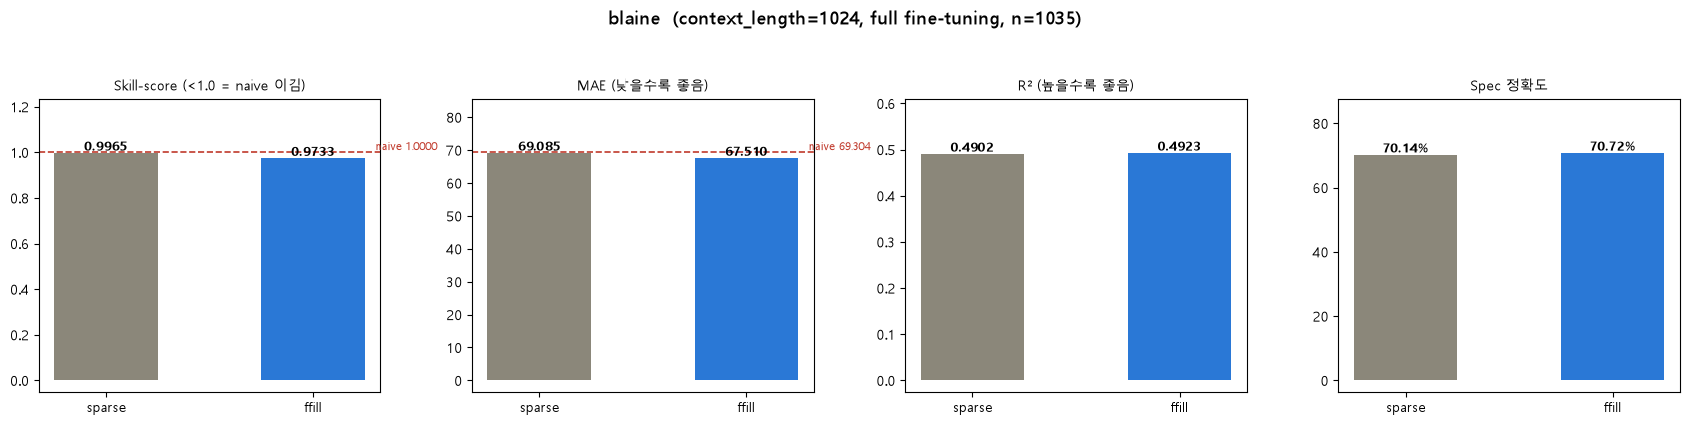

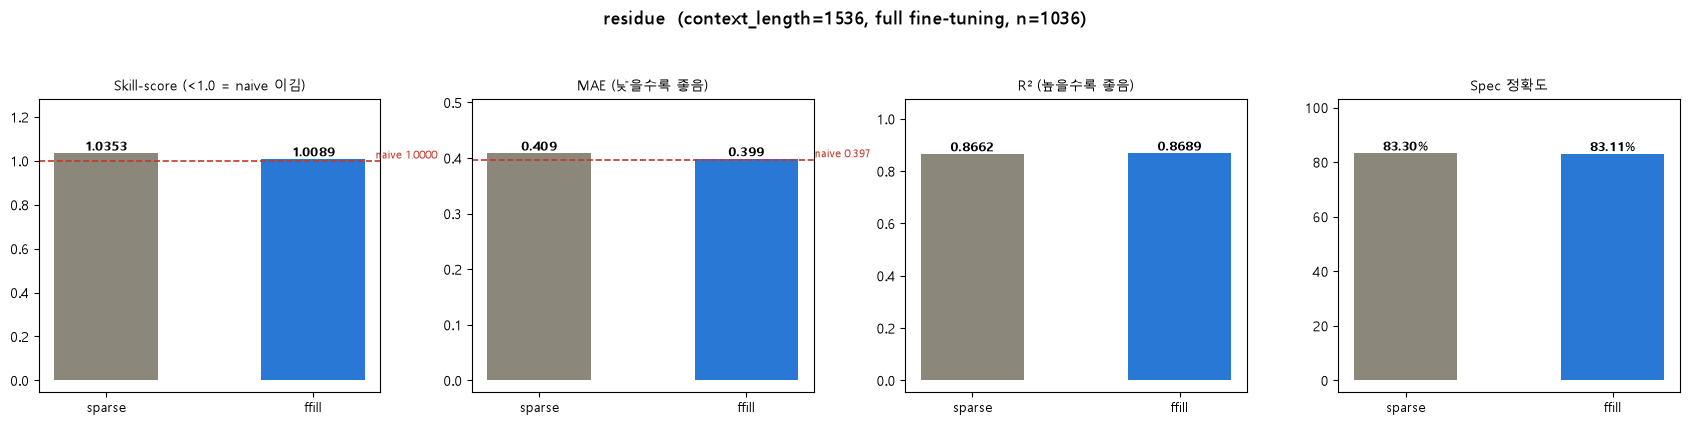

In [10]:
COLORS = {'sparse': '#8b877a', 'ffill': '#2a78d6'}

def plot_target(target):
    d = {a: res[target][a] for a in ARMS}
    m = {a: compute_metrics(d[a], cfg.SPEC_RANGES[target]) for a in ARMS}
    skill = {a: normalized_skill_score(d[a]) for a in ARMS}
    naive_mae = float(np.mean([np.abs(d[a]['actual'] - d[a]['naive_pred']).mean() for a in ARMS]))

    fig, axes = plt.subplots(1, 4, figsize=(17, 4))
    fig.suptitle(f'{target}  (context_length={CTX[target]}, full fine-tuning, n={len(d[ARMS[0]])})',
                 fontsize=13, fontweight='bold', y=1.05)

    def bars(ax, vals, title, fmt='{:.4f}', naive=None, pct=False):
        xs = np.arange(len(ARMS)); hs = [vals[a] for a in ARMS]
        b = ax.bar(xs, hs, color=[COLORS[a] for a in ARMS], width=0.5)
        for rect, v in zip(b, hs):
            ax.text(rect.get_x() + rect.get_width() / 2, v, fmt.format(v) + ('%' if pct else ''),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        if naive is not None:
            ax.axhline(naive, color='#c0392b', linestyle='--', linewidth=1.2)
            ax.text(len(ARMS) - 0.4, naive, f'naive {fmt.format(naive)}', fontsize=8,
                    color='#c0392b', va='bottom', ha='right')
        ax.set_xticks(xs); ax.set_xticklabels(ARMS, fontsize=9); ax.set_title(title, fontsize=10)
        lo, hi = ax.get_ylim(); ax.set_ylim(lo - (hi - lo) * 0.05, hi + (hi - lo) * 0.18)

    bars(axes[0], skill, 'Skill-score (<1.0 = naive 이김)', naive=1.0)
    bars(axes[1], {a: m[a]['MAE'] for a in ARMS}, 'MAE (낮을수록 좋음)', fmt='{:.3f}', naive=naive_mae)
    bars(axes[2], {a: m[a]['R2'] for a in ARMS}, 'R² (높을수록 좋음)')
    bars(axes[3], {a: m[a]['spec_accuracy'] * 100 for a in ARMS}, 'Spec 정확도', fmt='{:.2f}', pct=True)
    plt.tight_layout(); plt.show()

for t in cfg.TARGET_COLS:
    plot_target(t)

In [11]:
# 재학습 노이즈 기준선과 비교 (blaine skill-score 재현 편차 ~0.004, EXPERIMENT_LOG 2026-08-28)
NOISE = {'blaine': 0.004, 'residue': 0.004}
for target in cfg.TARGET_COLS:
    s = {a: normalized_skill_score(res[target][a]) for a in ARMS}
    delta = s['ffill'] - s['sparse']
    verdict = ('ffill 유리' if delta < -NOISE[target] else
               'sparse 유리' if delta > NOISE[target] else
               f'차이 없음 (|Δ| < 재학습 노이즈 {NOISE[target]})')
    print(f'{target:8s}  skill  sparse={s["sparse"]:.4f}  ffill={s["ffill"]:.4f}  '
          f'Δ(ffill-sparse)={delta:+.4f}  →  {verdict}')

blaine    skill  sparse=0.9965  ffill=0.9733  Δ(ffill-sparse)=-0.0233  →  ffill 유리
residue   skill  sparse=1.0353  ffill=1.0089  Δ(ffill-sparse)=-0.0264  →  ffill 유리


## 6. 결론 (2026-09-02 실행 완료)

**dense ffill 이 두 타깃 모두에서 유의미하게 낫다.**

| target | arm | MAE | R² | Spec % | 80% cov | skill-score |
|---|---|---|---|---|---|---|
| blaine | sparse (현행) | 69.08 | 0.490 | 70.1 | 44.4 | 0.9965 |
| blaine | **ffill** | **67.51** | 0.492 | 70.7 | 41.1 | **0.9733** |
| residue | sparse (현행) | 0.4089 | 0.866 | 83.3 | 50.0 | 1.0353 |
| residue | **ffill** | **0.3987** | 0.869 | 83.1 | 47.3 | **1.0089** |

- Δskill(ffill−sparse) = **blaine −0.023 / residue −0.026** → 재학습 노이즈(~0.004)의 6배. 방향·크기가 두 타깃에서 일관.
- MAE −2.3% / −2.5%, R² 소폭 개선. blaine 은 "겨우 naive 이기던" 상태(0.9965)에서 확실히 벗어남. residue 는 여전히 naive 미달(>1.0)이나 1.035→1.009 로 크게 좁힘.
- 80% 커버리지만 소폭 하락(44→41, 50→47) — 절대 수준이 목표(0.80)에서 멀어 노이즈 취급.
- 과거 sparse 근거("매 시간 반복 노출 → naive 로 붕괴 위험")는 기우였음. `fresh_reading_only` 평가라 "복사" 이득이 걸러진 상태에서의 개선.

**누출 감사(2절)**: D/B/A/C 전부 통과. ffill `_prev` 출처 lag min 4.0h / median 7.0h ≥ 4h → prediction_length ≤ 4 에서 누출 없음 (51,209행×3호기×2타깃 전수 검사).

### 다음
1. seed 2~3개로 재확인 (blaine ~18분/run, residue ~90분/run).
2. 재현되면 정식 파이프라인 기본값을 `prev_density="ffill"` 로 전환: `data/build_dataset.py` `main()`,
   `data/dataset_utils.py`·`config.py` 주석, 그리고 01/02 실험 build 스크립트도 함께.
3. `EXPERIMENT_LOG.md` 에 기록 완료.
